Imports & Configuration

In [ ]:

# Imports & Configuration
import os
import pandas as pd
import numpy as np
from scipy import sparse
from joblib import dump, load

# Preprocessors
from preprocessing.base_preprocessor import BasePreprocessor
from preprocessing.cbr_preprocessor import CBRPreprocessor
from preprocessing.sequence_preprocessor import SequencePreprocessor

# Visualization
from utils.plot_utils import (
    plot_class_distribution,
    plot_length_histogram,
    build_wordcloud_from_texts
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Configuration
config = {
    "lowercase": True,
    "remove_urls": True,
    "remove_emails": True,
    "remove_numbers": False,
    "remove_punctuation": True,
    "min_words": 1,
    "enable_outlier_analysis": True,
    "drop_nulls": True,
    "remove_duplicates": True,
    "max_seq_len": 120,
    "verbose": True,
    "stopwords":True
}

DATA_PATH = "Dataset\it_support_tickets.csv"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)


Load Dataset & Initial Preprocessing

In [ ]:
# Load Dataset
df = pd.read_csv("C:\\Users\\User\Downloads\\Intelligent final project\\Dataset\\it_support_tickets.csv")
print(f"Rows: {len(df)}, Columns: {df.columns.tolist()}")
df.head()

# Initialize preprocessors
base = BasePreprocessor(config)
cbr_prep = CBRPreprocessor(config)
seq_prep = SequencePreprocessor(config)

# Base cleaning
texts, labels = base.base_pipeline(df=df, text_col="Document", label_col="Topic_group")
df['cleaned_text'] = df['Document'].astype(str).apply(base.clean_text)

# Filter by min_words
if config.get("min_words", 0) > 0:
    df['n_words'] = df['cleaned_text'].apply(lambda t: len(t.split()))
    df = df[df['n_words'] >= config.get("min_words", 1)].reset_index(drop=True)

texts = df['cleaned_text'].tolist()
labels = df['Topic_group'] if 'Topic_group' in df.columns else None
print(f"After cleaning & filtering -> {len(texts)} documents")


Rows: 47837, Columns: ['Document', 'Topic_group']
[INFO] Null texts removed: 0
[INFO] Duplicate texts removed: 0
[INFO] Length outlier range: -17.5 – 3.5
After cleaning & filtering -> 47837 documents


Visualizations

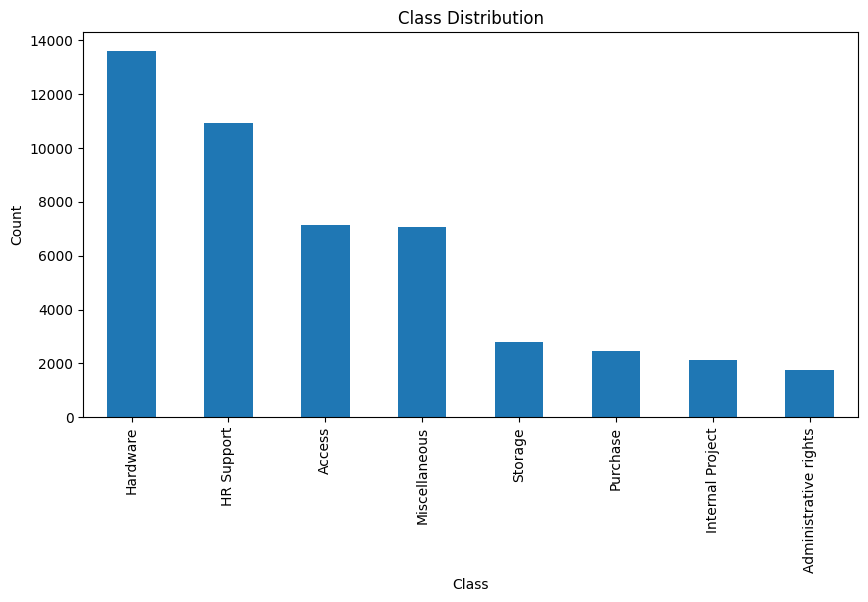

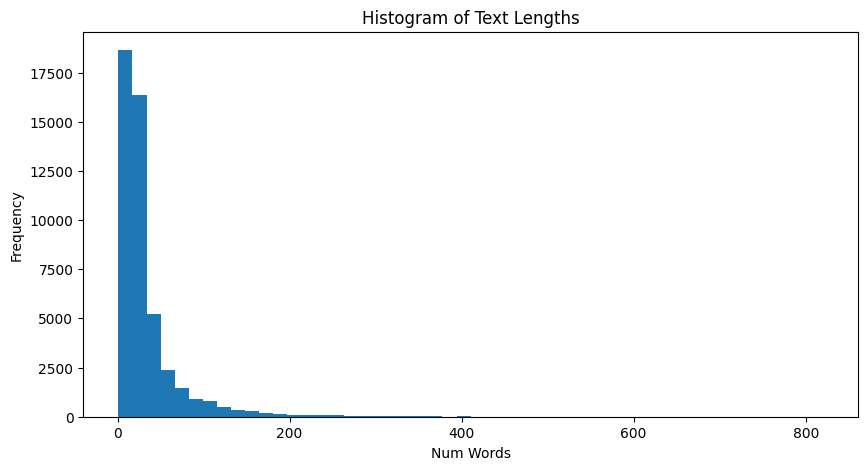

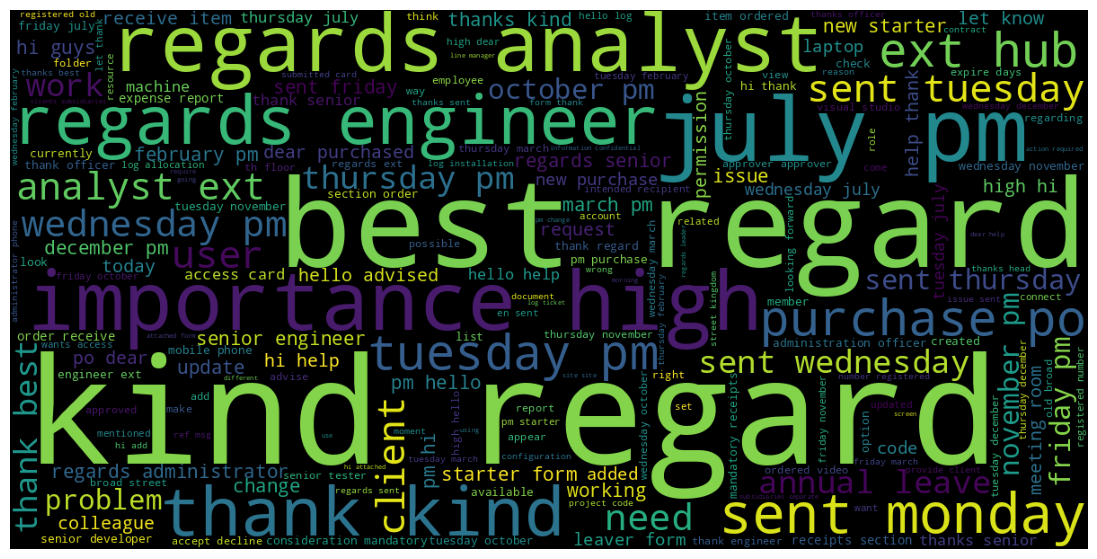

In [ ]:
# Visualization

# Class distribution
plot_class_distribution(
    labels,
    out_path=os.path.join(ARTIFACT_DIR, "class_distribution.png"),
    show=True
)

# Length histogram
plot_length_histogram(
    texts,
    out_path=os.path.join(ARTIFACT_DIR, "length_histogram.png"),
    show=True
)

# Word cloud
build_wordcloud_from_texts(
    texts,
    out_path=os.path.join(ARTIFACT_DIR, "wordcloud.png"),
    show=True
)


The dataset exhibits substantial class imbalance, with the largest class (Hardware) being 7.7× more frequent than the smallest class (Administrative rights). Since imbalanced distributions can bias similarity-based methods (e.g., k-NN in CBR) and affect neural sequence models, we recommend using class weighting and stratified splitting for the GRU model, and distance-weighted k-NN for the CBR system.


Prepare CBR Data

In [ ]:
# Prepare Case Base for CBR
df_cbr = pd.DataFrame({
    "case_id": range(len(df)),
    "description": df["cleaned_text"],
    "solution": df["Topic_group"]  # temporary placeholder
})

# TF-IDF preprocessing using CBRPreprocessor
X_tfidf = cbr_prep.fit_transform(df_cbr["description"].tolist())
sparse.save_npz(os.path.join(ARTIFACT_DIR, "tfidf_matrix.npz"), X_tfidf)
cbr_prep.save(os.path.join(ARTIFACT_DIR, "tfidf_vectorizer.joblib"))

print("TF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (47837, 15000)


CBR Model Definition

In [ ]:
# CBR Model
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

class CBRModel:
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
        self.nn = None
        self.case_base = None
        self.X = None

    def fit(self, df):
        self.case_base = df.reset_index(drop=True)
        corpus = df["description"].astype(str).tolist()
        self.X = self.vectorizer.fit_transform(corpus)
        self.nn = NearestNeighbors(
            n_neighbors=self.n_neighbors,
            metric="cosine"
        ).fit(self.X)

    def retrieve(self, query, top_k=3):
        qv = self.vectorizer.transform([query])
        dists, idxs = self.nn.kneighbors(qv, n_neighbors=top_k)

        results = []
        for dist, idx in zip(dists[0], idxs[0]):
            row = self.case_base.iloc[idx]
            sim = 1 - dist
            results.append({
                "case_id": row["case_id"],
                "description": row["description"],
                "solution": row["solution"],
                "similarity": float(sim)
            })
        return results

    def add_case(self, case_dict):
        self.case_base = pd.concat(
            [self.case_base, pd.DataFrame([case_dict])],
            ignore_index=True
        )
        self.fit(self.case_base)

    def save(self, path):
        joblib.dump(self.vectorizer, path + "_tfidf.joblib")
        self.case_base.to_csv(path + "_casebase.csv", index=False)

    def load(self, path):
        self.vectorizer = joblib.load(path + "_tfidf.joblib")
        self.case_base = pd.read_csv(path + "_casebase.csv")
        corpus = self.case_base["description"].astype(str).tolist()
        self.X = self.vectorizer.transform(corpus)
        self.nn = NearestNeighbors(
            n_neighbors=self.n_neighbors, metric="cosine"
        ).fit(self.X)


Prepare GRU Sequences

In [ ]:
# Sequence preprocessing for GRU
X_seq = seq_prep.fit_transform(texts)
np.save(os.path.join(ARTIFACT_DIR, "sequences.npy"), X_seq)
seq_prep.save(os.path.join(ARTIFACT_DIR, "tokenizer.joblib"))

# Prepare labels
y = labels.astype('category').cat.codes.values
num_classes = len(np.unique(y))

# Train/Val split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y, stratify=y, test_size=0.2, random_state=42
)

vocab_size = len(seq_prep.tokenizer.word_index) + 1
max_len = config["max_seq_len"]

print("Sequences prepared for GRU. Shape:", X_seq.shape)


Sequences prepared for GRU. Shape: (47837, 120)


GRU Model Definition

In [ ]:
# GRU Model
class GRUModel:
    def __init__(self, vocab_size, max_len, num_classes, embed_dim=128, gru_units=128):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.num_classes = num_classes

        self.model = Sequential([
            Embedding(vocab_size, embed_dim, input_length=max_len),
            GRU(gru_units),
            Dropout(0.3),
            Dense(128, activation="relu"),
            Dense(num_classes, activation="softmax")
        ])

        self.model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

    def train(self, X_train, y_train, X_val, y_val, epochs=10, batch_size=32):
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        return self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=1
        )

    def predict(self, seq):
        pred = self.model.predict(np.array([seq]))
        class_id = np.argmax(pred)
        confidence = float(np.max(pred))
        return class_id, confidence

    def save(self, path):
        self.model.save(path + "_model.h5")

    def load(self, path):
        self.model = tf.keras.models.load_model(path + "_model.h5")


Train GRU & CBR

In [ ]:
# Train GRU
gru_model = GRUModel(vocab_size, max_len, num_classes)
history = gru_model.train(X_train, y_train, X_val, y_val, epochs=10, batch_size=32)

# Train CBR
cbr_model = CBRModel()
cbr_model.fit(df_cbr)

# Save models
gru_model.save(os.path.join(ARTIFACT_DIR, "gru"))
cbr_model.save(os.path.join(ARTIFACT_DIR, "cbr"))

print("GRU & CBR models trained and saved successfully.")


Epoch 1/10


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1196/1196 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.2896 - loss: 1.8292 - val_accuracy: 0.4475 - val_loss: 1.5339
Epoch 2/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 64s 53ms/step - accuracy: 0.7633 - loss: 0.6905 - val_accuracy: 0.8564 - val_loss: 0.4185
Epoch 3/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - accuracy: 0.8762 - loss: 0.3585 - val_accuracy: 0.8546 - val_loss: 0.4097
Epoch 4/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9051 - loss: 0.2796 - val_accuracy: 0.8613 - val_loss: 0.4042
Epoch 5/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 70s 58ms/step - accuracy: 0.9225 - loss: 0.2219 - val_accuracy: 0.8545 - val_loss: 0.4516
Epoch 6/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 67s 56ms/step - accuracy: 0.9380 - loss: 0.1774 - val_accuracy: 0.8506 - val_loss: 0.4839
Epoch 7/10
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9522 - loss: 0.1371 - val_accuracy: 0.8448 - val_loss: 0.5688


GRU & CBR models trained and saved successfully.
